<img src = seattle_logo.jpg
     align = 'right'></a>
<span style="color:navy; font-size:28px; font-weight:bold;">Anticipation des besoins en consommation énergétique des bâtiments non-résidentiels</span>    
<span style="font-size:24px; font-weight:bold;">2. Prédiction de la consommation totale d'énergie</span>

In [1]:
import sys
import time
import warnings

import numpy as np
import pandas as pd

import sklearn
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.neighbors import KNeighborsRegressor

import shap
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Version de Python et des librairies utilisées
print("Python version", sys.version)
print("Environnement :", sys.executable[:-11])
print("-"*110)
print("> numpy : version", np.__version__)
print("> pandas : version", pd.__version__)
print("> scikit-learn : version", sklearn.__version__)
print("> matplotlib : version", matplotlib.__version__)
print("> seaborn : version", sns.__version__)
print("> SHAP : version", shap.__version__)

Python version 3.11.5 | packaged by conda-forge | (main, Aug 27 2023, 03:23:48) [MSC v.1936 64 bit (AMD64)]
Environnement : C:\Users\guill\anaconda3\envs\DS-P4
--------------------------------------------------------------------------------------------------------------
> numpy : version 1.24.3
> pandas : version 2.1.4
> scikit-learn : version 1.3.0
> matplotlib : version 3.8.0
> seaborn : version 0.13.2
> SHAP : version 0.42.1


In [3]:
# Options :
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
shap.progress_bar = tqdm
shap.initjs()
seed = 11

# Préparation

In [4]:
# Importation des données :
data = pd.read_csv('data.csv')

In [5]:
# Importation de la liste des bâtiments pour leur identification :
properties = pd.read_csv('2016_Building_Energy_Benchmarking.csv')
properties = properties[['OSEBuildingID', 'PropertyName', 'ListOfAllPropertyUseTypes', 'SiteEnergyUse(kBtu)']]

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1541 entries, 0 to 1540
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   OSEBuildingID           1541 non-null   int64  
 1   PrimaryPropertyType     1541 non-null   object 
 2   Neighborhood            1541 non-null   object 
 3   PropertyAge             1541 non-null   int64  
 4   NumberofBuildings       1541 non-null   float64
 5   NumberofFloors          1541 non-null   int64  
 6   PropertyGFABuilding(s)  1541 non-null   int64  
 7   Access_Steam            1541 non-null   int64  
 8   Access_NaturalGas       1541 non-null   int64  
 9   SiteEnergyUse(kBtu)     1541 non-null   float64
 10  TotalGHGEmissions       1541 non-null   float64
dtypes: float64(3), int64(6), object(2)
memory usage: 132.6+ KB


## Séparation en ensembles d'entraînement et de test

In [7]:
# Séparation des variables indépendantes et de la cible :
X = data.drop(columns=['OSEBuildingID', 'TotalGHGEmissions', 'SiteEnergyUse(kBtu)', 'NumberofBuildings', 'Neighborhood'])
y = data['SiteEnergyUse(kBtu)']
ID = data['OSEBuildingID']

In [8]:
# Split des données en un jeu d'entraîment et un jeu de test :
X_train, X_test, y_train, y_test, ID_train, ID_test = train_test_split(
    X, y, ID,
    test_size=0.2,
    stratify=X['PrimaryPropertyType'],
    random_state=seed
)

## Transformation de la cible

La cible sera transformeée logarithmiquement pour l'entraînement des modèles (puis retransformée à l'échelle réelle en sortie) afin que la distribution des valeurs de celle-ci se rapproche d'une distribution normale.

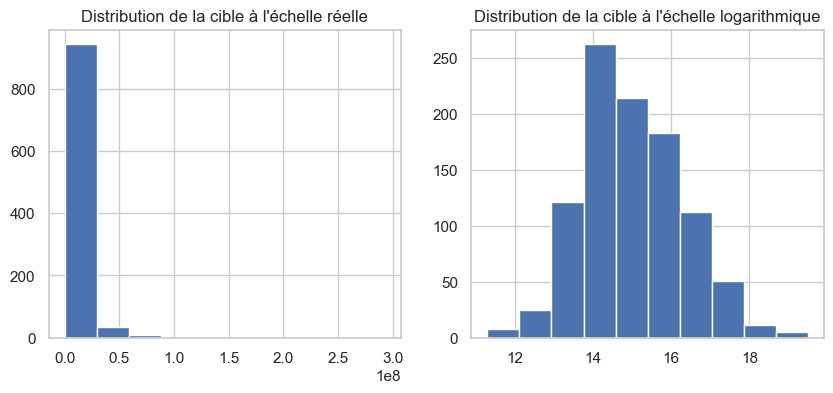

In [121]:
# Affichage des effets de la transformation logarithmique de la cible :
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(y)
ax[0].set_title("Distribution de la cible à l'échelle réelle")
ax[1].hist(np.log(y))
ax[1].set_title("Distribution de la cible à l'échelle logarithmique")
plt.show()

## Définition des variables à normaliser et à encoder

In [11]:
features_to_scale = ['PropertyAge', 'NumberofFloors', 'PropertyGFABuilding(s)']
features_to_encode = ['PrimaryPropertyType']

## Définition des fonctions

In [12]:
def Standard_Scaler(Xf):
    """Applique un StandardScaler() aux données
    Paramètre : Données à traiter (pd.DataFrame, np.array)
    """
    X_scaled = Xf.copy()
    scaler = StandardScaler().fit(X_train[features_to_scale])
    X_scaled[features_to_scale] = scaler.transform(X_scaled[features_to_scale])
    return X_scaled

# Définition du FunctionTransformer correspondant :
standard_scaler = FunctionTransformer(Standard_Scaler)

In [13]:
def MinMax_Scaler(Xf):
    """Applique un MinMaxScaler() aux données
    Paramètre : Données à traiter (pd.DataFrame, np.array)
    """
    X_scaled = Xf.copy()
    scaler = MinMaxScaler().fit(X_train[features_to_scale])
    X_scaled[features_to_scale] = scaler.transform(X_scaled[features_to_scale])
    return X_scaled

# Définition du FunctionTransformer correspondant :
minmax_scaler = FunctionTransformer(MinMax_Scaler)

In [14]:
def Robust_Scaler(Xf):
    """Applique un RobustScaler() aux données
    Paramètre : Données à traiter (pd.DataFrame, np.array)
    """
    X_scaled = Xf.copy()
    scaler = RobustScaler().fit(X_train[features_to_scale])
    X_scaled[features_to_scale] = scaler.transform(X_scaled[features_to_scale])
    return X_scaled

# Définition du FunctionTransformer correspondant :
robust_scaler = FunctionTransformer(Robust_Scaler)

In [15]:
def One_Hot_Encoder(Xf):
    """Applique un OneHotEncoder() aux données
    Paramètre : Données à traiter (pd.DataFrame, np.array)
    """
    X_encoded = Xf.copy()
    encoder = OneHotEncoder(categories='auto', handle_unknown='ignore')
    encoder.fit(X[features_to_encode])
    encoded_cols = encoder.transform(X_encoded[features_to_encode])
    encoded_cols = pd.DataFrame(encoded_cols.toarray(), columns=encoder.get_feature_names_out(), index=X_encoded.index)
    X_encoded = pd.concat([X_encoded.drop(columns=features_to_encode), encoded_cols], axis=1)
    return X_encoded

# Définition du FunctionTransformer correspondant :
one_hot_encoder = FunctionTransformer(One_Hot_Encoder)

In [16]:
def mean_absolute_percentage_error(y_true, y_pred):
    """Calcule le Pourcentage d'Erreur Absolue Moyen entre 2 séries réelle et prédite
    Paramètres : Données réelles, Données prédites (np.array)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Définition du scorer correspondant :
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

In [17]:
def performance_metrics(model, Xtrain, ytrain, Xtest, ytest, name='Pipeline', cv=5):
    """Calcule la performance d'un modèle (R², RMSE, MAE, MAPE) par validation croisée
    et sur les train et test sets, ainsi que ses temps d'entraînement et de prédiction.
    Paramètres : Modèle,
                 Xtrain, Xtest (pd.DataFrame, np.array),
                 ytrain, ytest (np.array),
                 Nom du modèle (str),
                 Nombre de plis de validation croisée (int)
    """
    clone_model = clone(model)
    scoring = {
        'r2': 'r2', 
        'neg_mean_squared_error': 'neg_mean_squared_error', 
        'neg_mean_absolute_error': 'neg_mean_absolute_error', 
        'mean_absolute_percentage_error': mape_scorer
    }
    cv_results = cross_validate(model, Xtrain, ytrain, scoring=scoring, cv=cv)
    i = 'Cross Validation TRAIN SET'
    cv_metrics = pd.DataFrame({
        (i, 'R² CV'): cv_results['test_r2'].mean(),
        (i, 'Std(R²)'): cv_results['test_r2'].std(),
        (i, 'RMSE CV'): np.sqrt(-cv_results['test_neg_mean_squared_error']).mean(),
        (i, 'Std(RMSE)'): np.sqrt(-cv_results['test_neg_mean_squared_error']).std(),
        (i, 'MAE CV'): -cv_results['test_neg_mean_absolute_error'].mean(),
        (i, 'Std(MAE)'): -cv_results['test_neg_mean_absolute_error'].std(),
        (i, 'MAPE CV'): -cv_results['test_mean_absolute_percentage_error'].mean(),
        (i, 'Std(MAPE)'): -cv_results['test_mean_absolute_percentage_error'].std(),
    }, index=[name]
                             )
    start = time.time()
    clone_model.fit(Xtrain, ytrain)
    fit_time = (time.time() - start)*1000
    
    start = time.time()
    ytrain_predict = clone_model.predict(Xtrain)
    predict_time = (time.time() - start)*1000
    
    ytest_predict = clone_model.predict(Xtest)
    
    j = 'TRAIN SET'
    train_metrics = pd.DataFrame({
        (j, 'R² train'): r2_score(ytrain, ytrain_predict),
        (j, 'RMSE train'): mean_squared_error(ytrain, ytrain_predict, squared=False),
        (j, 'MAE train'): mean_absolute_error(ytrain, ytrain_predict),
        (j, 'MAPE train'): mean_absolute_percentage_error(ytrain, ytrain_predict)
    }, index=[name]
                                )
    k = 'TEST SET'
    test_metrics = pd.DataFrame({
        (k, 'R² test'): r2_score(ytest, ytest_predict),
        (k, 'RMSE test'): mean_squared_error(ytest, ytest_predict, squared=False),
        (k, 'MAE test'): mean_absolute_error(ytest, ytest_predict),
        (k, 'MAPE test'): mean_absolute_percentage_error(ytest, ytest_predict)
    }, index=[name]
                                )
    l = 'TIME (ms)'
    time_metrics = pd.DataFrame({
        (l, 'Fit'): fit_time,
        (l, 'Predict'): predict_time
    }, index=[name]
                                )
    results = pd.concat([cv_metrics, train_metrics, test_metrics, time_metrics], axis=1)
    
    return results

# Entrainement des modèles

## Régression linéaire de base

In [18]:
# Instanciation d'un modèle Linear Regression :
lr = LinearRegression()

In [19]:
# Création du pipeline avec transformation des données et modèle :
lr_pipe = make_pipeline(
    minmax_scaler,
    one_hot_encoder,
    TransformedTargetRegressor(regressor=lr, func=np.log, inverse_func=np.exp)
    )

In [20]:
# Calcul des performances du modèle sur les 2 ensembles :
performance_metrics(lr_pipe, X_train, y_train, X_test, y_test, 'Linear Regression')

Cross Validation TRAIN SET                           \
                                       R² CV    Std(R²)       RMSE CV   
Linear Regression                 -55.818166  52.268737  1.212494e+08   

                                                                        \
                      Std(RMSE)        MAE CV      Std(MAE)    MAPE CV   
Linear Regression  9.783936e+07  1.216636e+07 -7.273155e+06  83.944498   

                             TRAIN SET                                         \
                  Std(MAPE)   R² train    RMSE train     MAE train MAPE train   
Linear Regression -5.993944 -31.358568  9.896588e+07  9.136137e+06  79.753613   

                   TEST SET                                       TIME (ms)  \
                    R² test     RMSE test      MAE test MAPE test       Fit   
Linear Regression  0.502348  1.439492e+07  5.395977e+06  84.68428  5.505323   

                              
                     Predict  
Linear Regression  12.678862

## ElasticNet

In [21]:
# Instanciation d'un modèle ElasticNet :
elasticnet = ElasticNet()

In [22]:
# Création du pipeline avec transformation des données et modèle :
elasticnet_pipe = make_pipeline(
    minmax_scaler,
    one_hot_encoder,
    TransformedTargetRegressor(regressor=elasticnet, func=np.log, inverse_func=np.exp)
)

In [23]:
# Calcul des performances du modèle sur les 2 ensembles :
performance_metrics(elasticnet_pipe, X_train, y_train, X_test, y_test, 'ElasticNet Base')

Cross Validation TRAIN SET                          \
                                     R² CV   Std(R²)       RMSE CV   
ElasticNet Base                  -0.074587  0.012465  1.731286e+07   

                                                                       \
                    Std(RMSE)        MAE CV       Std(MAE)    MAPE CV   
ElasticNet Base  4.786590e+06  6.233310e+06 -836023.378646  156.30544   

                           TRAIN SET                                          \
                 Std(MAPE)  R² train    RMSE train     MAE train  MAPE train   
ElasticNet Base -12.967094 -0.065871  1.796152e+07  6.230372e+06  156.060224   

                 TEST SET                                         TIME (ms)  \
                  R² test     RMSE test      MAE test   MAPE test       Fit   
ElasticNet Base -0.089486  2.129891e+07  7.850007e+06  183.967744  9.509087   

                           
                  Predict  
ElasticNet Base  7.507801

### Optimisation

In [24]:
# Définition des hyperparamètres à tester et de leurs valeurs :
param_grid = {
    'transformedtargetregressor__regressor__alpha': [0.01, 0.05, 0.1, 1.0, 10.0],
    'transformedtargetregressor__regressor__l1_ratio': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
}

In [25]:
# Instanciation d'une validation croisée Grid Search :
grid_search = GridSearchCV(elasticnet_pipe, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error')

In [26]:
# Entraînement de la validation croisée :
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('functiontransformer-1',
                                        FunctionTransformer(func=<function MinMax_Scaler at 0x000001FD71122C00>)),
                                       ('functiontransformer-2',
                                        FunctionTransformer(func=<function One_Hot_Encoder at 0x000001FD71123420>)),
                                       ('transformedtargetregressor',
                                        TransformedTargetRegressor(func=<ufunc 'log'>,
                                                                   inverse_func=<ufunc 'exp'>,
                                                                   regressor=ElasticNet()))]),
             param_grid={'transformedtargetregressor__regressor__alpha': [0.01,
                                                                          0.05,
                                                                          0.1,
                                                                          1.0,
                                                                          10.0],
                         'transformedtargetregressor__regressor__l1_ratio': [0.1,
                                                                             0.2,
                                                                             0.3,
                                                                             0.4,
                                                                             0.5,
                                                                             0.6,
                                                                             0.7,
                                                                             0.8,
                                                                             0.9]},
             scoring='neg_root_mean_squared_error')

In [27]:
# Enregistrement des meilleurs modèle et paramètres :
elasticnet_best_model = grid_search.best_estimator_
elasticnet_best_params = grid_search.best_params_

In [28]:
# Affichage des meilleurs paramètres trouvés par Grid Search :
print("Meilleurs paramètres :")
display(elasticnet_best_params)

Meilleurs paramètres :


{'transformedtargetregressor__regressor__alpha': 0.01,
 'transformedtargetregressor__regressor__l1_ratio': 0.3}

### Performance

In [29]:
# Calcul des performances du modèle sur les 2 ensembles :
en_metrics = performance_metrics(elasticnet_best_model, X_train, y_train, X_test, y_test, 'ElasticNet')
display(en_metrics)

Cross Validation TRAIN SET                                       \
                                R² CV  Std(R²)       RMSE CV     Std(RMSE)   
ElasticNet                   0.279842  0.15982  1.378659e+07  3.393340e+06   

                                                             TRAIN SET  \
                  MAE CV       Std(MAE)    MAPE CV Std(MAPE)  R² train   
ElasticNet  4.616140e+06 -764977.333381  87.475821 -5.996503  0.373776   

                                                   TEST SET                \
              RMSE train     MAE train MAPE train   R² test     RMSE test   
ElasticNet  1.376751e+07  4.541103e+06  85.845132  0.119987  1.914217e+07   

                                    TIME (ms)           
                MAE test  MAPE test       Fit  Predict  
ElasticNet  6.199503e+06  95.885958  9.342432  5.36418

## SVR

In [30]:
# Instanciation d'un modèle SupportVectorRegressor :
svr = SVR()

In [31]:
# Création du pipeline avec transformation des données et modèle :
svr_pipe = make_pipeline(
    standard_scaler,
    one_hot_encoder,
    TransformedTargetRegressor(regressor=svr, func=np.log, inverse_func=np.exp)
)

In [32]:
# Calcul des performances du modèle sur les 2 ensembles :
performance_metrics(svr_pipe, X_train, y_train, X_test, y_test, 'SVR')

Cross Validation TRAIN SET                                        \
                         R² CV   Std(R²)       RMSE CV     Std(RMSE)   
SVR                   0.484578  0.199879  1.235892e+07  5.474384e+06   

                                                      TRAIN SET                \
           MAE CV       Std(MAE)    MAPE CV Std(MAPE)  R² train    RMSE train   
SVR  3.453835e+06 -724021.824012  59.500634 -2.627455  0.622136  1.069445e+07   

                              TEST SET                                        \
        MAE train MAPE train   R² test     RMSE test      MAE test MAPE test   
SVR  2.716400e+06  51.885457  0.465497  1.491837e+07  4.504966e+06  62.39094   

    TIME (ms)              
          Fit     Predict  
SVR  78.21846  114.840031

### Optimisation

In [33]:
# Définition des hyperparamètres à tester et de leurs valeurs :
param_grid = {
    'transformedtargetregressor__regressor__C': [0.1, 1, 10],
    'transformedtargetregressor__regressor__kernel': ['linear', 'rbf', 'poly'],
    'transformedtargetregressor__regressor__gamma': ['scale', 'auto'],
    'transformedtargetregressor__regressor__epsilon': [0.1, 0.2, 0.5],
    'transformedtargetregressor__regressor__tol': [1e-3, 1e-4],
    'transformedtargetregressor__regressor__degree': [2, 3, 4]
}

In [34]:
# Instanciation d'une validation croisée Randomized Search :
grid_search = RandomizedSearchCV(svr_pipe, param_grid, scoring='neg_root_mean_squared_error', cv=5, random_state=seed)

In [35]:
# Entraînement de la validation croisée :
grid_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('functiontransformer-1',
                                              FunctionTransformer(func=<function Standard_Scaler at 0x000001FD71122700>)),
                                             ('functiontransformer-2',
                                              FunctionTransformer(func=<function One_Hot_Encoder at 0x000001FD71123420>)),
                                             ('transformedtargetregressor',
                                              TransformedTargetRegressor(func=<ufunc 'log'>,
                                                                         inverse_func=<ufunc 'exp'>,
                                                                         reg...
                                        'transformedtargetregressor__regressor__degree': [2,
                                                                                          3,
                                                                                          4],
                                        'transformedtargetregressor__regressor__epsilon': [0.1,
                                                                                           0.2,
                                                                                           0.5],
                                        'transformedtargetregressor__regressor__gamma': ['scale',
                                                                                         'auto'],
                                        'transformedtargetregressor__regressor__kernel': ['linear',
                                                                                          'rbf',
                                                                                          'poly'],
                                        'transformedtargetregressor__regressor__tol': [0.001,
                                                                                       0.0001]},
                   random_state=11, scoring='neg_root_mean_squared_error')

In [36]:
# Enregistrement des meilleurs modèle et paramètres :
svr_best_model = grid_search.best_estimator_
svr_best_params = grid_search.best_params_

In [37]:
# Affichage des meilleurs paramètres trouvés :
print("Meilleurs paramètres :")
display(svr_best_params)

Meilleurs paramètres :


{'transformedtargetregressor__regressor__tol': 0.0001,
 'transformedtargetregressor__regressor__kernel': 'rbf',
 'transformedtargetregressor__regressor__gamma': 'auto',
 'transformedtargetregressor__regressor__epsilon': 0.1,
 'transformedtargetregressor__regressor__degree': 3,
 'transformedtargetregressor__regressor__C': 1}

### Performance

In [38]:
# Calcul des performances du modèle sur les 2 ensembles :
svr_metrics = performance_metrics(svr_best_model, X_train, y_train, X_test, y_test, 'SVR')
display(svr_metrics)

Cross Validation TRAIN SET                                        \
                         R² CV   Std(R²)       RMSE CV     Std(RMSE)   
SVR                   0.525025  0.170503  1.179832e+07  4.911284e+06   

                                                      TRAIN SET                \
           MAE CV       Std(MAE)    MAPE CV Std(MAPE)  R² train    RMSE train   
SVR  3.613229e+06 -715865.931993  64.780434 -2.673847  0.587119  1.117901e+07   

                              TEST SET                                         \
        MAE train MAPE train   R² test     RMSE test      MAE test  MAPE test   
SVR  3.290376e+06   61.01119  0.547209  1.373078e+07  4.751745e+06  72.047469   

     TIME (ms)              
           Fit     Predict  
SVR  78.148365  111.581802

## Random Forest

In [39]:
# Instanciation d'un modèle RandomForestRegressor :
rfr = RandomForestRegressor(random_state=seed)

In [40]:
# Création du pipeline avec transformation des données et modèle :
rfr_pipe = make_pipeline(
    one_hot_encoder,
    TransformedTargetRegressor(regressor=rfr, func=np.log, inverse_func=np.exp)
)

In [41]:
# Calcul des performances du modèle sur les 2 ensembles :
performance_metrics(rfr_pipe, X_train, y_train, X_test, y_test, 'RandomForest Base')

Cross Validation TRAIN SET                          \
                                       R² CV   Std(R²)       RMSE CV   
RandomForest Base                   0.715003  0.087686  8.929158e+06   

                                                                        \
                      Std(RMSE)        MAE CV      Std(MAE)    MAPE CV   
RandomForest Base  2.950269e+06  3.191790e+06 -525048.36909  63.797842   

                            TRAIN SET                                         \
                  Std(MAPE)  R² train    RMSE train     MAE train MAPE train   
RandomForest Base -5.831293  0.924327  4.785881e+06  1.356652e+06  19.244607   

                   TEST SET                                         \
                    R² test     RMSE test      MAE test  MAPE test   
RandomForest Base  0.676662  1.160312e+07  4.248103e+06  71.234368   

                    TIME (ms)             
                          Fit    Predict  
RandomForest Base  796.648026  34.877062

### Optimisation

In [42]:
# Définition des hyperparamètres à tester et de leurs valeurs :
param_grid = {
    'transformedtargetregressor__regressor__n_estimators': [100, 200, 500],
    'transformedtargetregressor__regressor__max_features': [None, 'sqrt', 'log2'],
    'transformedtargetregressor__regressor__max_depth': [None, 5, 10, 15],
    'transformedtargetregressor__regressor__min_samples_split': [2, 5, 10],
    'transformedtargetregressor__regressor__min_samples_leaf': [1, 2, 4],
}

In [43]:
# Instanciation d'une validation croisée Randomized Search :
grid_search = RandomizedSearchCV(rfr_pipe, param_grid, scoring='neg_root_mean_squared_error', cv=5, random_state=seed)

In [44]:
# Entraînement de la validation croisée :
grid_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('functiontransformer',
                                              FunctionTransformer(func=<function One_Hot_Encoder at 0x000001FD71123420>)),
                                             ('transformedtargetregressor',
                                              TransformedTargetRegressor(func=<ufunc 'log'>,
                                                                         inverse_func=<ufunc 'exp'>,
                                                                         regressor=RandomForestRegressor(random_state=11)))]),
                   param_distributions={'transformedtargetregressor__...h': [None,
                                                                                             5,
                                                                                             10,
                                                                                             15],
                                        'transformedtargetregressor__regressor__max_features': [None,
                                                                                                'sqrt',
                                                                                                'log2'],
                                        'transformedtargetregressor__regressor__min_samples_leaf': [1,
                                                                                                    2,
                                                                                                    4],
                                        'transformedtargetregressor__regressor__min_samples_split': [2,
                                                                                                     5,
                                                                                                     10],
                                        'transformedtargetregressor__regressor__n_estimators': [100,
                                                                                                200,
                                                                                                500]},
                   random_state=11, scoring='neg_root_mean_squared_error')

In [45]:
# Enregistrement des meilleurs modèle et paramètres :
rfr_best_model = grid_search.best_estimator_
rfr_best_params = grid_search.best_params_

In [46]:
# Affichage des meilleurs paramètres trouvés :
print("Meilleurs paramètres :")
display(rfr_best_params)

Meilleurs paramètres :


{'transformedtargetregressor__regressor__n_estimators': 500,
 'transformedtargetregressor__regressor__min_samples_split': 5,
 'transformedtargetregressor__regressor__min_samples_leaf': 2,
 'transformedtargetregressor__regressor__max_features': None,
 'transformedtargetregressor__regressor__max_depth': None}

### Performance

In [47]:
# Calcul des performances du modèle sur les 2 ensembles :
rfr_metrics = performance_metrics(rfr_best_model, X_train, y_train, X_test, y_test, 'RandomForest')
display(rfr_metrics)

Cross Validation TRAIN SET                                        \
                                  R² CV   Std(R²)       RMSE CV     Std(RMSE)   
RandomForest                    0.66403  0.097193  9.837425e+06  3.607228e+06   

                                                               TRAIN SET  \
                    MAE CV       Std(MAE)    MAPE CV Std(MAPE)  R² train   
RandomForest  3.298322e+06 -587839.382099  63.737639 -5.020626  0.843063   

                                                     TEST SET                \
                RMSE train     MAE train MAPE train   R² test     RMSE test   
RandomForest  6.892136e+06  1.870723e+06  29.230515  0.635771  1.231497e+07   

                                         TIME (ms)              
                  MAE test  MAPE test          Fit     Predict  
RandomForest  4.379616e+06  69.823941  3134.222984  109.955549

## Gradient Boosting

In [48]:
# Instanciation d'un modèle GradientBoostingRegressor :
gbr = GradientBoostingRegressor(random_state=seed+1)

In [49]:
# Création du pipeline avec transformation des données et modèle :
gbr_pipe = make_pipeline(
    one_hot_encoder,
    TransformedTargetRegressor(regressor=gbr, func=np.log, inverse_func=np.exp)
)

In [50]:
# Calcul des performances du modèle sur les 2 ensembles :
performance_metrics(gbr_pipe, X_train, y_train, X_test, y_test, 'GradientBoosting Base')

Cross Validation TRAIN SET                          \
                                           R² CV   Std(R²)       RMSE CV   
GradientBoosting Base                   0.726925  0.148557  8.332693e+06   

                                                                             \
                          Std(RMSE)        MAE CV       Std(MAE)    MAPE CV   
GradientBoosting Base  2.909519e+06  3.004562e+06 -524383.345578  58.355363   

                                TRAIN SET                              \
                      Std(MAPE)  R² train    RMSE train     MAE train   
GradientBoosting Base  -2.95946  0.863809  6.420455e+06  2.459270e+06   

                                  TEST SET                              \
                      MAPE train   R² test     RMSE test      MAE test   
GradientBoosting Base  46.326782  0.714866  1.089610e+07  4.244287e+06   

                                   TIME (ms)          
                       MAPE test         Fit Predict  
GradientBoosting Base  65.474616  188.875914     0.0

### Optimisation

In [51]:
# Définition des hyperparamètres à tester et de leurs valeurs :
param_grid = {
    'transformedtargetregressor__regressor__learning_rate': [0.01, 0.1, 0.3, 0.5],
    'transformedtargetregressor__regressor__max_depth': [3, 5, 7, 9],
    'transformedtargetregressor__regressor__n_estimators': [50, 100, 200],
    'transformedtargetregressor__regressor__min_samples_split': [2, 5, 10],
    'transformedtargetregressor__regressor__min_samples_leaf': [1, 2, 4],
    'transformedtargetregressor__regressor__subsample': [0.5, 0.75, 1.0]
}

In [52]:
# Instanciation d'une validation croisée Randomized Search :
grid_search = RandomizedSearchCV(gbr_pipe, param_grid, cv=5, scoring='neg_root_mean_squared_error', random_state=seed)

In [53]:
# Entraînement de la validation croisée :
grid_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('functiontransformer',
                                              FunctionTransformer(func=<function One_Hot_Encoder at 0x000001FD71123420>)),
                                             ('transformedtargetregressor',
                                              TransformedTargetRegressor(func=<ufunc 'log'>,
                                                                         inverse_func=<ufunc 'exp'>,
                                                                         regressor=GradientBoostingRegressor(random_state=12)))]),
                   param_distributions={'transformedtargetregress...
                                        'transformedtargetregressor__regressor__max_depth': [3,
                                                                                             5,
                                                                                             7,
                                                                                             9],
                                        'transformedtargetregressor__regressor__min_samples_leaf': [1,
                                                                                                    2,
                                                                                                    4],
                                        'transformedtargetregressor__regressor__min_samples_split': [2,
                                                                                                     5,
                                                                                                     10],
                                        'transformedtargetregressor__regressor__n_estimators': [50,
                                                                                                100,
                                                                                                200],
                                        'transformedtargetregressor__regressor__subsample': [0.5,
                                                                                             0.75,
                                                                                             1.0]},
                   random_state=11, scoring='neg_root_mean_squared_error')

In [54]:
# Enregistrement des meilleurs modèle et paramètres :
gbr_best_model = grid_search.best_estimator_
gbr_best_params = grid_search.best_params_

In [55]:
# Affichage des meilleurs paramètres trouvés :
print("Meilleurs paramètres :")
display(gbr_best_params)

Meilleurs paramètres :


{'transformedtargetregressor__regressor__subsample': 0.75,
 'transformedtargetregressor__regressor__n_estimators': 100,
 'transformedtargetregressor__regressor__min_samples_split': 5,
 'transformedtargetregressor__regressor__min_samples_leaf': 2,
 'transformedtargetregressor__regressor__max_depth': 3,
 'transformedtargetregressor__regressor__learning_rate': 0.3}

### Performance

In [56]:
# Calcul des performances du modèle sur les 2 ensembles :
gbr_metrics = performance_metrics(gbr_best_model, X_train, y_train, X_test, y_test, 'GradientBoosting')
display(gbr_metrics)

Cross Validation TRAIN SET                          \
                                      R² CV   Std(R²)       RMSE CV   
GradientBoosting                   0.744121  0.164533  7.518758e+06   

                                                                        \
                     Std(RMSE)        MAE CV       Std(MAE)    MAPE CV   
GradientBoosting  1.789072e+06  2.969858e+06 -375508.160362  60.634464   

                           TRAIN SET                                         \
                 Std(MAPE)  R² train    RMSE train     MAE train MAPE train   
GradientBoosting -2.752085  0.923403  4.815007e+06  1.951621e+06  36.518959   

                  TEST SET                                          TIME (ms)  \
                   R² test     RMSE test      MAE test  MAPE test         Fit   
GradientBoosting  0.688616  1.138662e+07  4.231057e+06  64.449277  157.631159   

                             
                    Predict  
GradientBoosting  14.545202

# Comparatif et choix du modèle final

In [57]:
def compare_scores(score):
    """Compare les métriques de performance sur forme de plots.
    Paramètre : DataFrame concaténé issu de la fonction performance_metrics
    """
    s_cv = score + ' CV'
    s_cv_text = score + ' Cross Val'
    s_std = 'Std(' + score + ')'
    s_std_text = 'Ecart-type ' + score + ' CV'
    s_train = score + ' train'
    s_test = score + ' test'

    plt.figure(figsize=(len(metrics)*2, 6))
    plt.plot(metrics[s_cv], label=s_cv_text, color='g', marker='o')
    plt.fill_between(
        metrics.index,
        metrics[s_cv] - metrics[s_std], metrics[s_cv] + metrics[s_std],
        color='green', alpha=0.1, label=s_std_text
    )
    plt.plot(metrics[s_train], label=s_train, marker='o')
    plt.plot(metrics[s_test], label=s_test, color='darkorange', marker='o')
    plt.ylim(0, None)
    plt.ylabel(score)
    plt.title("Comparaison des " + score + "\n")
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.show()

In [58]:
# Concaténation des performances des modèles :
metrics = pd.concat([
    en_metrics,
    svr_metrics,
    rfr_metrics,
    gbr_metrics
])
display(metrics)

Cross Validation TRAIN SET                          \
                                      R² CV   Std(R²)       RMSE CV   
ElasticNet                         0.279842  0.159820  1.378659e+07   
SVR                                0.525025  0.170503  1.179832e+07   
RandomForest                       0.664030  0.097193  9.837425e+06   
GradientBoosting                   0.744121  0.164533  7.518758e+06   

                                                                        \
                     Std(RMSE)        MAE CV       Std(MAE)    MAPE CV   
ElasticNet        3.393340e+06  4.616140e+06 -764977.333381  87.475821   
SVR               4.911284e+06  3.613229e+06 -715865.931993  64.780434   
RandomForest      3.607228e+06  3.298322e+06 -587839.382099  63.737639   
GradientBoosting  1.789072e+06  2.969858e+06 -375508.160362  60.634464   

                           TRAIN SET                                         \
                 Std(MAPE)  R² train    RMSE train     MAE train MAPE train   
ElasticNet       -5.996503  0.373776  1.376751e+07  4.541103e+06  85.845132   
SVR              -2.673847  0.587119  1.117901e+07  3.290376e+06  61.011190   
RandomForest     -5.020626  0.843063  6.892136e+06  1.870723e+06  29.230515   
GradientBoosting -2.752085  0.923403  4.815007e+06  1.951621e+06  36.518959   

                  TEST SET                                         \
                   R² test     RMSE test      MAE test  MAPE test   
ElasticNet        0.119987  1.914217e+07  6.199503e+06  95.885958   
SVR               0.547209  1.373078e+07  4.751745e+06  72.047469   
RandomForest      0.635771  1.231497e+07  4.379616e+06  69.823941   
GradientBoosting  0.688616  1.138662e+07  4.231057e+06  64.449277   

                    TIME (ms)              
                          Fit     Predict  
ElasticNet           9.342432    5.364180  
SVR                 78.148365  111.581802  
RandomForest      3134.222984  109.955549  
GradientBoosting   157.631159   14.545202

In [59]:
metrics.columns = metrics.columns.droplevel(0)

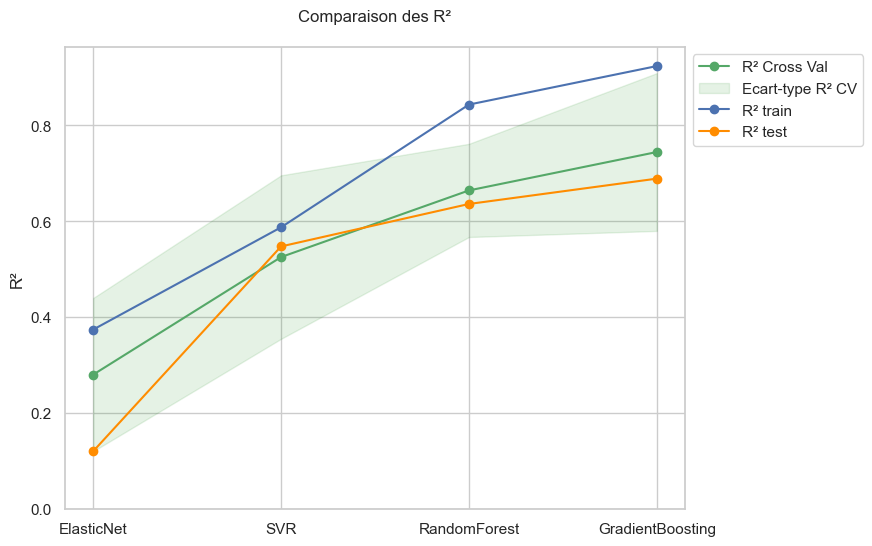

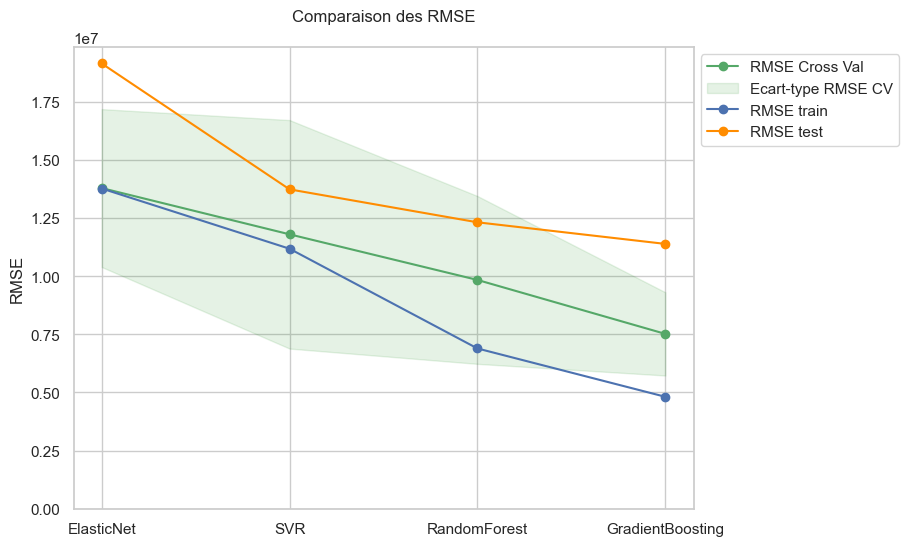

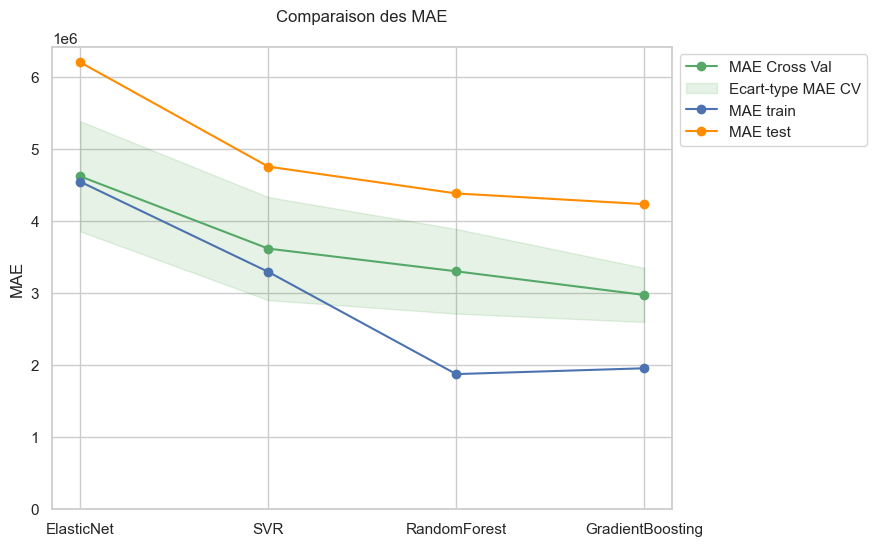

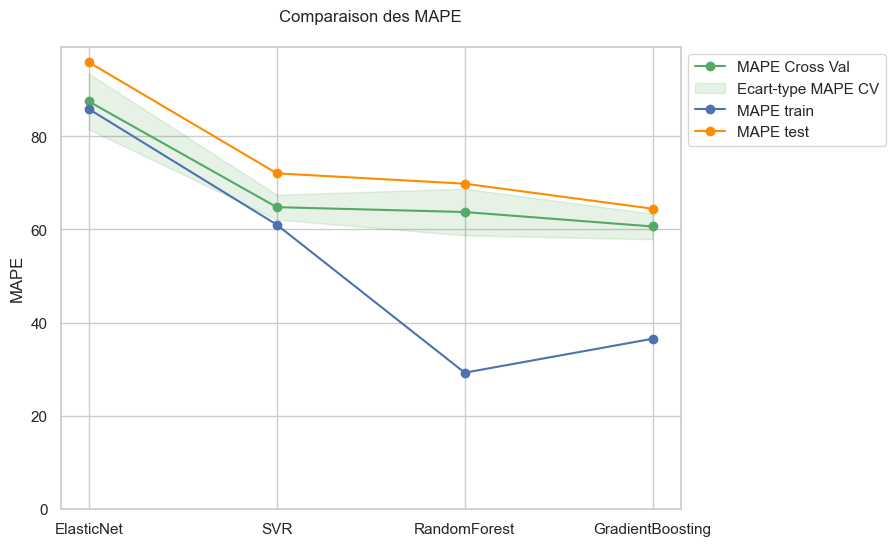

In [60]:
# Comparatif des scores sous forme de plot :
for i in ['R²', 'RMSE', 'MAE', 'MAPE']:
    compare_scores(i)

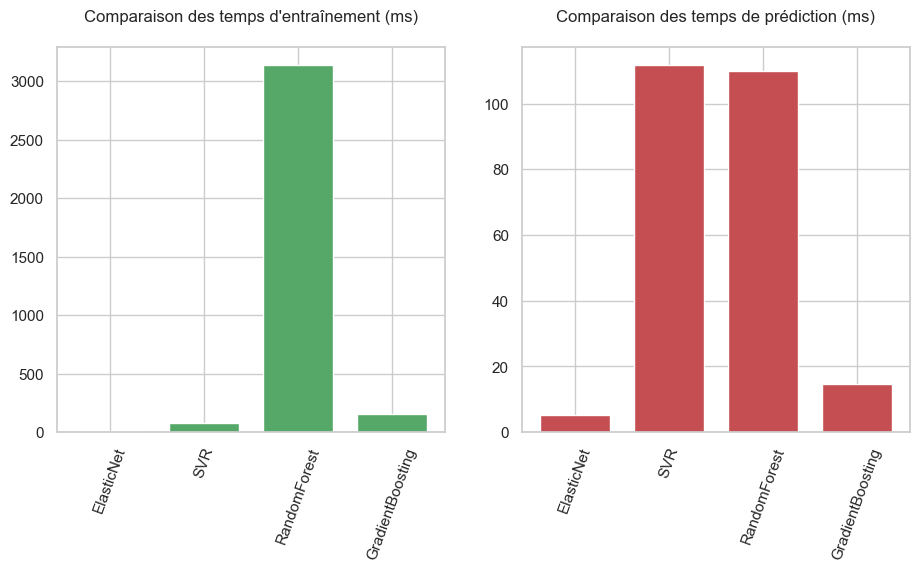

In [61]:
# Comparatif du temps d'ntraînement et prédiction :
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].bar(metrics.index, metrics['Fit'], width=.75, color='g')
ax[1].bar(metrics.index, metrics['Predict'], width=.75, color='r')
ax[0].set_title("Comparaison des temps d'entraînement (ms)\n")
ax[1].set_title("Comparaison des temps de prédiction (ms)\n")
for axis in ax:
    axis.set_xticks(metrics.index)
    axis.set_xticklabels(metrics.index, rotation=70)
plt.show()

Le modèle GradientBoostingRegressor affiche les meilleurs performances sur presque l'ensemble des métriques analysées, nous retiendrons donc celui-ci.

# Interprétabilité du modèle

## Feature importance globale (modèle)

In [62]:
# Extraction des feature importances du modèle :
feature_importances = gbr_best_model.named_steps['transformedtargetregressor'].regressor_.feature_importances_
feature_names = gbr_best_model.named_steps['transformedtargetregressor'].regressor_.feature_names_in_

In [63]:
# Création de l'importance des variables :
feature_importance = pd.DataFrame({'Variable': feature_names, 'Importance': feature_importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

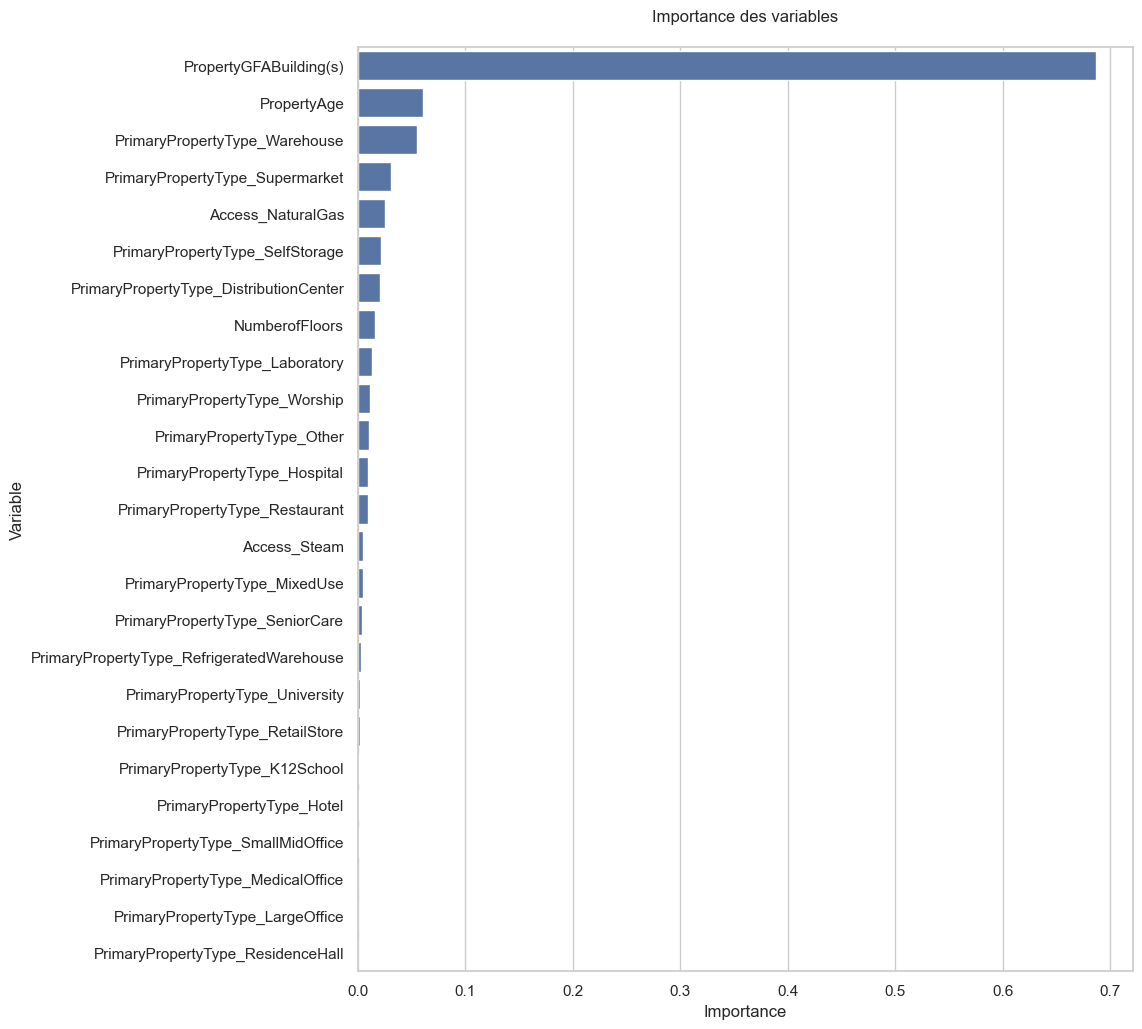

In [64]:
# Graphique de l'importance des variables :
plt.figure(figsize=(10, 12))
sns.barplot(data=feature_importance, x='Importance', y='Variable')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Importance des variables\n')
plt.show()

## Interprétabilité globale (SHAP)

In [65]:
# Extraction du régresseur du pipeline :
best_regressor = gbr_best_model.named_steps['transformedtargetregressor'].regressor
best_regressor.fit(One_Hot_Encoder(X_train), np.log(y_train))

GradientBoostingRegressor(learning_rate=0.3, min_samples_leaf=2,
                          min_samples_split=5, random_state=12, subsample=0.75)

In [66]:
# Création de l'explainer SHAP pour GradientBoostingRegressor :
explainer = shap.TreeExplainer(best_regressor)

In [67]:
# Calcul des valeurs SHAP pour toutes les instances de X_test :
shap_values = explainer.shap_values(One_Hot_Encoder(X_test))

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


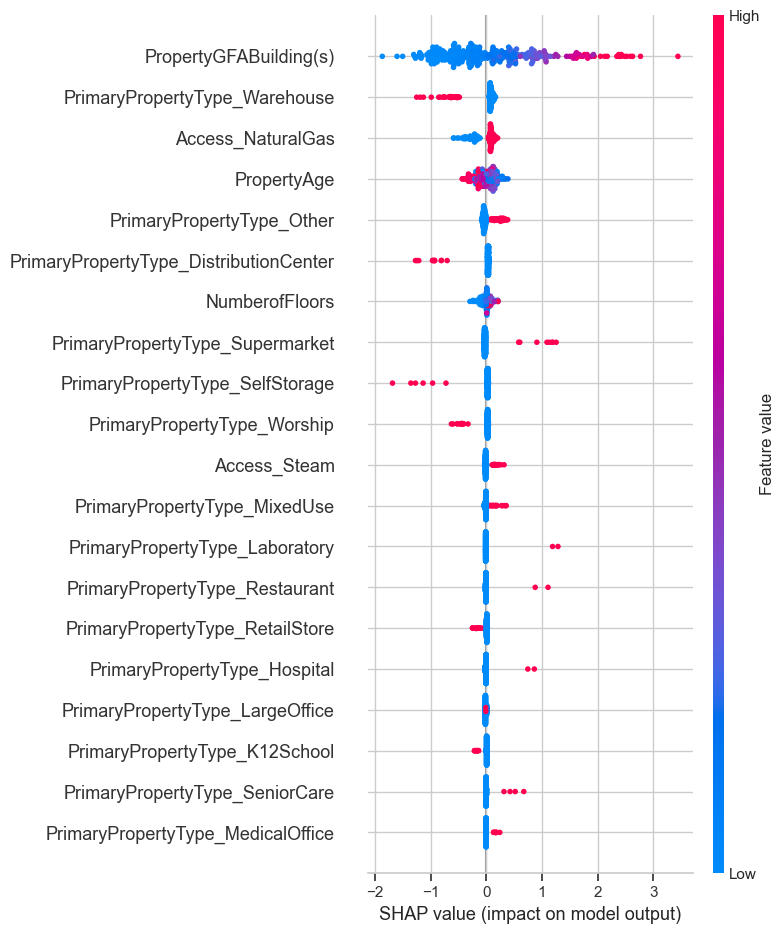

In [68]:
# Affichage de l'interprétabilité globale :
shap.summary_plot(shap_values, One_Hot_Encoder(X_test))

## Interprétabilité locale

### Plus faible consommation

In [69]:
# Sélection de la consommation la plus faible :
i = np.argmin(y_test)

In [70]:
# Calcul des valeurs SHAP pour l'instance à expliquer :
shap_values = explainer.shap_values(One_Hot_Encoder(X_test.iloc[[i]]))

In [71]:
# Affichage des valeurs SHAP :
print("Interprétabilité locale : plus faible consommation")
display(properties.loc[properties['OSEBuildingID'] == ID_test.iloc[i], :])
shap.force_plot(explainer.expected_value, shap_values, One_Hot_Encoder(X_test.iloc[[i]]))

Interprétabilité locale : plus faible consommation


,OSEBuildingID,PropertyName,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
974,20396,Meaves Building,"Non-Refrigerated Warehouse, Retail Store",90558.70313


### Consommation médiane

In [72]:
# Sélection de la consommation médiane :
i = np.where(np.isclose(y_test, np.median(y_test), atol=0.00005))[0][0]

In [73]:
# Calcul des valeurs SHAP pour l'instance à expliquer :
shap_values = explainer.shap_values(One_Hot_Encoder(X_test.iloc[[i]]))

In [74]:
# Affichage des valeurs SHAP :
print("Interprétabilité locale : consommation médiane")
display(properties.loc[properties['OSEBuildingID'] == ID_test.iloc[i], :])
shap.force_plot(explainer.expected_value, shap_values, One_Hot_Encoder(X_test.iloc[[i]]))

Interprétabilité locale : consommation médiane


,OSEBuildingID,PropertyName,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
237,361,Yesler Building,Office,2746560.75


### Plus forte consommation

In [75]:
# Sélection de la consommation la plus importante :
i = np.argmax(y_test)

In [76]:
# Calcul des valeurs SHAP pour l'instance à expliquer :
shap_values = explainer.shap_values(One_Hot_Encoder(X_test.iloc[[i]]))

In [77]:
# Affichage des valeurs SHAP :
print("Interprétabilité locale : plus forte consommation")
display(properties.loc[properties['OSEBuildingID'] == ID_test.iloc[i], :])
shap.force_plot(explainer.expected_value, shap_values, One_Hot_Encoder(X_test.iloc[[i]]))

Interprétabilité locale : plus forte consommation


,OSEBuildingID,PropertyName,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
124,198,Seattle Children's Hospital Main Campus,Hospital (General Medical & Surgical),253832464.0


# Analyse des erreurs et résidus

In [78]:
# Prédiction :
y_train_pred = gbr_best_model.predict(X_train)
y_test_pred = gbr_best_model.predict(X_test)

## Erreurs

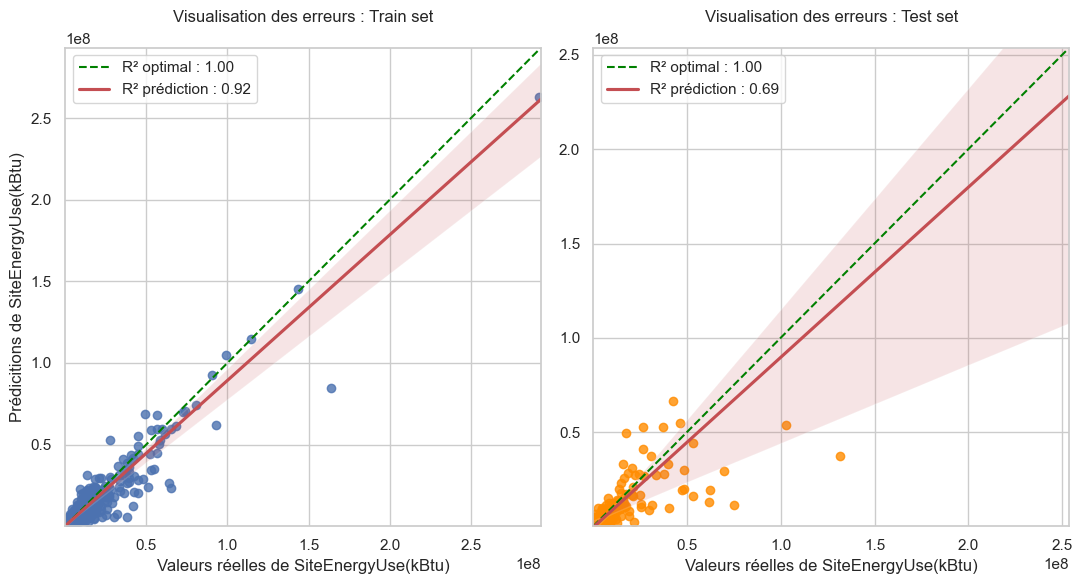

In [79]:
# Calcul des R² :
r2_train = r2_score(y_train, y_train_pred).round(2)
r2_test = r2_score(y_test, y_test_pred).round(2)

fig, ax = plt.subplots(1, 2, figsize=(11, 6))

# Affichage des erreurs sur l'ensemble d'entraînement :
ax[0].plot([0, 1e9], [0, 1e9], linestyle='--', color='green', label="R² optimal : 1.00")
sns.regplot(x=y_train, y=y_train_pred, line_kws={'color': 'r', 'label': "R² prédiction : "+str(r2_train)}, ax=ax[0])
ax[0].set(xlim=(min(y_train), max(y_train)), ylim=(min(y_train), max(y_train)), title="Visualisation des erreurs : Train set\n",
          xlabel="Valeurs réelles de "+y_train.name, ylabel="Prédicitions de "+y_train.name)
ax[0].legend()

# Affichage des erreurs sur l'ensemble de test :
ax[1].plot([0, 1e9], [0, 1e9], linestyle='--', color='green', label="R² optimal : 1.00")
sns.regplot(x=y_test, y=y_test_pred, line_kws={'color': 'r', 'label': "R² prédiction : "+str(r2_test)}, ax=ax[1], color='darkorange')
ax[1].set(xlim=(min(y_test), max(y_test)), ylim=(min(y_test), max(y_test)), title="Visualisation des erreurs : Test set\n",
          xlabel="Valeurs réelles de "+y_test.name, ylabel=None)
ax[1].legend()

plt.tight_layout()
plt.show()

## Résidus

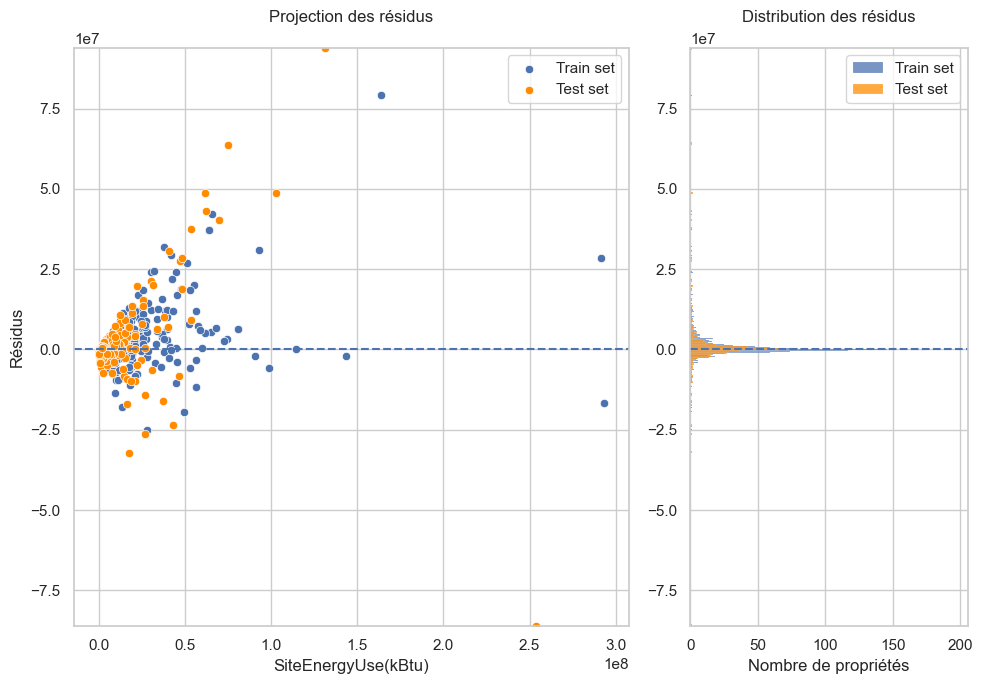

In [80]:
# Calcul des résidus :
train_resid = y_train - y_train_pred
test_resid = y_test - y_test_pred
ymin = min(min(train_resid), min(test_resid))
ymax = max(max(train_resid), max(test_resid))

fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw = {'width_ratios': [2, 1]})

# Affichage des résidus sur les 2 ensembles :
sns.scatterplot(x=y_train, y=train_resid, ax=ax[0], label="Train set")
sns.scatterplot(x=y_test, y=test_resid, ax=ax[0], label="Test set", color='darkorange')
ax[0].axhline(y=0, linestyle='--')
ax[0].set(ylabel="Résidus", title="Projection des résidus\n", ylim=(ymin, ymax))

# Affichage de la distribution des résidus :
sns.histplot(y=train_resid, ax=ax[1], label="Train set")
sns.histplot(y=test_resid, ax=ax[1], label="Test set", color='darkorange')
ax[1].set(ylim=(ymin, ymax), title="Distribution des résidus\n", xlabel="Nombre de propriétés", ylabel=None)
ax[1].axhline(y=0, linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()

In [81]:
# Identification des 10 plus importants résidus sur l'ensemble d'entraînement :
train_top10resid = pd.DataFrame({'OSEBuildingID': ID_train, 'Réel': y_train, 'Prédit': y_train_pred, 'Résidu': y_train_pred - y_train})
train_top10resid = pd.merge(train_top10resid, properties, on='OSEBuildingID', how='left')
train_top10resid = train_top10resid.sort_values(by='Résidu', key=abs, ascending=False).head(10)
print("Résidus TRAIN :")
display(train_top10resid)

Résidus TRAIN :


,OSEBuildingID,Réel,Prédit,Résidu,PropertyName,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
338,49940,163945984.0,8.485346e+07,-7.909252e+07,Virginia Mason Medical Center - 2149,Hospital (General Medical & Surgical),163945984.0
325,338,65336980.0,2.318806e+07,-4.214892e+07,Jack R. McDonald Building,Other,65336980.0
288,637,63835192.0,2.663279e+07,-3.720240e+07,Stadium Innovation Center,"Distribution Center, Office, Other, Other - Re...",63835192.0
724,803,37951708.0,5.955382e+06,-3.199633e+07,200 SW Michigan,Office,37951708.0
258,775,92937640.0,6.208997e+07,-3.084767e+07,Columbia Center - 2015,"Office, Parking",92937640.0
138,49780,41680640.0,1.234358e+07,-2.933706e+07,2020 Fifth Avenue Dat Center,"Data Center, Parking",41680640.0
1,828,291614432.0,2.631752e+08,-2.843919e+07,Swedish First Hill,"Hospital (General Medical & Surgical), Parking",291614432.0
822,49972,51168308.0,2.421213e+07,-2.695618e+07,Computer Science and Electrical Engineering,College/University,51168308.0
1044,25992,27684480.0,5.266926e+07,2.498478e+07,2201 / Enso Condominiums - SEDO,"Multifamily Housing, Office, Parking, Restaurant",27684480.0
747,49709,31803568.0,7.430986e+06,-2.437258e+07,"Seattle ProCure Management, LLC.",Urgent Care/Clinic/Other Outpatient,31803568.0


In [82]:
# Identification des 10 plus importants résidus sur l'ensemble de test :
test_top10resid = pd.DataFrame({'OSEBuildingID': ID_test, 'Réel': y_test, 'Prédit': y_test_pred, 'Résidu': y_test_pred - y_test})
test_top10resid = pd.merge(test_top10resid, properties, on='OSEBuildingID', how='left')
test_top10resid = test_top10resid.sort_values(by='Résidu', key=abs, ascending=False).head(10)
print("Résidus TEST :")
display(test_top10resid)

Résidus TEST :


,OSEBuildingID,Réel,Prédit,Résidu,PropertyName,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
269,477,131373880.0,3.745266e+07,-9.392122e+07,Weintraub/Hutchinson/Thomas,"Other, Parking",131373880.0
138,198,253832464.0,3.399816e+08,8.614912e+07,Seattle Children's Hospital Main Campus,Hospital (General Medical & Surgical),253832464.0
20,440,75073888.0,1.125902e+07,-6.381487e+07,Fisher Plaza - West Building,"Data Center, Financial Office, Office, Other, ...",75073888.0
189,466,61762380.0,1.292822e+07,-4.883416e+07,VM Seattle Hospital & Medical Center - Buck Pa...,Urgent Care/Clinic/Other Outpatient,61762380.0
252,23113,102673696.0,5.400935e+07,-4.866434e+07,Central Campus,"Medical Office, Other/Specialty Hospital, Outp...",102673696.0
13,295,62197176.0,1.904080e+07,-4.315637e+07,1122 3rd Ave,Other,62197176.0
169,355,69519808.0,2.923345e+07,-4.028635e+07,901 Fifth Avenue,"Financial Office, Office, Parking, Retail Store",69519808.0
39,261,53466684.0,1.587763e+07,-3.758905e+07,South Park,"Laboratory, Non-Refrigerated Warehouse, Office...",53466684.0
103,433,17666646.0,4.976294e+07,3.209630e+07,(71367A) SEATTLE Macy's,"Other, Retail Store",17666646.0
272,48287,40613740.0,9.990023e+06,-3.062372e+07,Central Link Operations and Maintenance Facility,"Office, Other - Services",40613740.0


## Pourcentage d'erreur

In [83]:
train_error_rate = train_resid*100 / y_train
test_error_rate = test_resid*100 / y_test

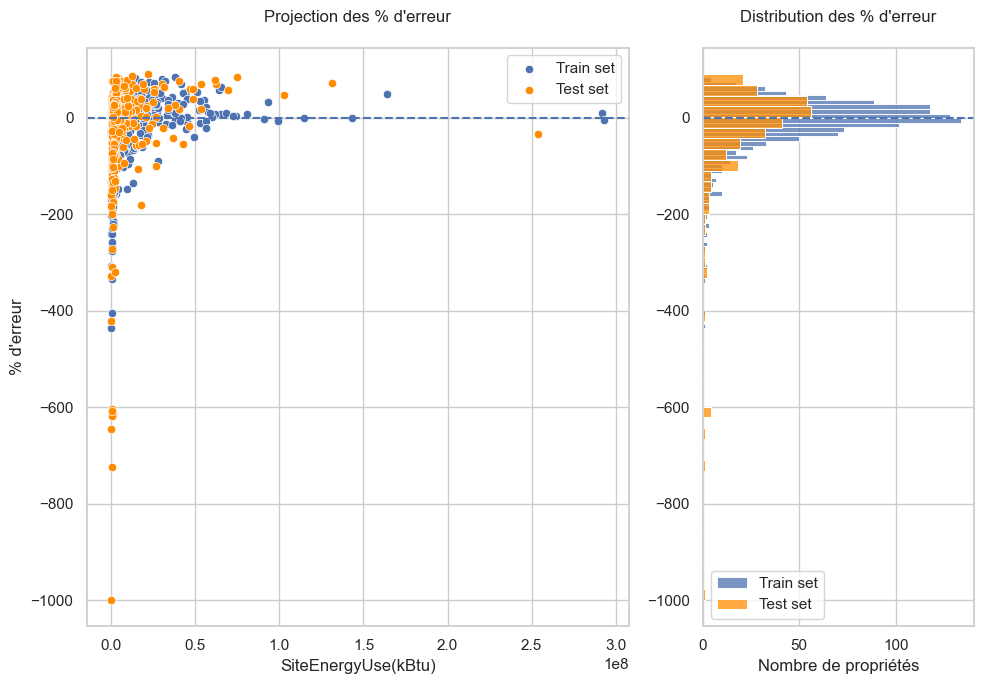

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw = {'width_ratios': [2, 1]})

# Affichage des % d'erreur sur les 2 ensembles :
sns.scatterplot(x=y_train, y=train_error_rate, ax=ax[0], label="Train set")
sns.scatterplot(x=y_test, y=test_error_rate, ax=ax[0], label="Test set", color='darkorange')
ax[0].axhline(y=0, linestyle='--')
ax[0].set(ylabel="% d'erreur", title="Projection des % d'erreur\n")

# Affichage de la distribution des % d'erreur :
sns.histplot(y=train_error_rate, ax=ax[1], label="Train set")
sns.histplot(y=test_error_rate, ax=ax[1], label="Test set", color='darkorange')
ax[1].set(title="Distribution des % d'erreur\n", xlabel="Nombre de propriétés", ylabel=None)
ax[1].axhline(y=0, linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()

In [85]:
# Identification des 10 plus importants % d'erreur sur l'ensemble d'entraînement :
train_top10error = pd.DataFrame({'OSEBuildingID': ID_train, 'Réel': y_train, 'Prédit': y_train_pred, '% Erreur': train_error_rate})
train_top10error = pd.merge(train_top10error, properties, on='OSEBuildingID', how='left')
train_top10error = train_top10error.sort_values(by='% Erreur', key=abs, ascending=False).head(10)
print("Résidus TRAIN :")
display(train_top10error)

Résidus TRAIN :


,OSEBuildingID,Réel,Prédit,% Erreur,PropertyName,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
51,27869,79711.79688,4.277224e+05,-436.586060,Auto Accessories Inc.,Non-Refrigerated Warehouse,79711.79688
952,530,227566.70310,1.146433e+06,-403.778929,Magnum Building,Non-Refrigerated Warehouse,227566.70310
867,26126,690557.68750,3.004514e+06,-335.085161,(ID26126) THE SUMMIT,Other - Entertainment/Public Assembly,690557.68750
544,22327,306911.09380,1.311825e+06,-327.428379,Ballard Masonic Center,Social/Meeting Hall,306911.09380
1036,24099,652991.68750,2.674731e+06,-309.611845,Thermal Supply,Other,652991.68750
74,23342,113130.00000,4.602441e+05,-306.827630,Daily Racing Form,Non-Refrigerated Warehouse,113130.00000
680,550,325513.00000,1.221214e+06,-275.166118,21517-Seattle / Aurora AVE N,Non-Refrigerated Warehouse,325513.00000
172,21270,456953.00000,1.667345e+06,-264.883272,Rex Land Building (Block 56SE) - SEDO,"Non-Refrigerated Warehouse, Office",456953.00000
1138,41,318364.81250,1.138606e+06,-257.641833,08781-University Village,Self-Storage Facility,318364.81250
273,797,151754.29690,5.181106e+05,-241.414129,Westcore River Street,Distribution Center,151754.29690


In [86]:
# Identification des 10 plus importants % d'erreur sur l'ensemble de test :
test_top10error = pd.DataFrame({'OSEBuildingID': ID_test, 'Réel': y_test, 'Prédit': y_test_pred, '% Erreur': test_error_rate})
test_top10error = pd.merge(test_top10error, properties, on='OSEBuildingID', how='left')
test_top10error = test_top10error.sort_values(by='% Erreur', key=abs, ascending=False).head(10)
print("Résidus TRAIN :")
display(test_top10error)

Résidus TRAIN :


,OSEBuildingID,Réel,Prédit,% Erreur,PropertyName,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
152,24758,1.119697e+05,1.230331e+06,-998.806710,TRW Building,"Parking, Self-Storage Facility",1.119697e+05
293,24415,6.005169e+05,4.942597e+06,-723.057217,Aurora Improvements,"Distribution Center, Non-Refrigerated Warehous...",6.005169e+05
168,20396,9.055870e+04,6.744700e+05,-644.787608,Meaves Building,"Non-Refrigerated Warehouse, Retail Store",9.055870e+04
170,49872,5.441724e+05,3.905426e+06,-617.681857,Mercedes-Benz of Seattle,"Automobile Dealership, Parking",5.441724e+05
71,25711,8.999242e+05,6.440231e+06,-615.641483,BUSH GARDEN - RESTURANT & LOUNGE,Restaurant,8.999242e+05
305,22504,2.222559e+05,1.573863e+06,-608.131213,"MER Equipment,Inc.",Manufacturing/Industrial Plant,2.222559e+05
299,20470,2.671351e+05,1.878888e+06,-603.347553,Lake City Center - Main Building,"Food Service, Retail Store, Supermarket/Grocer...",2.671351e+05
145,27553,1.273740e+05,6.633523e+05,-420.790979,DAE II,Non-Refrigerated Warehouse,1.273740e+05
28,25554,1.887457e+05,8.071911e+05,-327.660631,Alaskan Way,Other,1.887457e+05
277,594,2.339814e+06,9.819370e+06,-319.664505,McKinstry SEA - 220 S Hudson Shop,Other,2.339814e+06


# Intérêt de l'ENERGY STAR Score

In [87]:
# Importation des données :
data = pd.read_csv('data_score.csv')

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   OSEBuildingID           992 non-null    int64  
 1   PrimaryPropertyType     992 non-null    object 
 2   Neighborhood            992 non-null    object 
 3   PropertyAge             992 non-null    int64  
 4   NumberofBuildings       992 non-null    float64
 5   NumberofFloors          992 non-null    int64  
 6   PropertyGFABuilding(s)  992 non-null    int64  
 7   Access_Steam            992 non-null    int64  
 8   Access_NaturalGas       992 non-null    int64  
 9   ENERGYSTARScore         992 non-null    float64
 10  SiteEnergyUse(kBtu)     992 non-null    float64
 11  TotalGHGEmissions       992 non-null    float64
dtypes: float64(4), int64(6), object(2)
memory usage: 93.1+ KB


In [89]:
# Séparation des variables indépendantes et de la cible :
X = data.drop(columns=['OSEBuildingID', 'TotalGHGEmissions', 'SiteEnergyUse(kBtu)', 'ENERGYSTARScore', 'NumberofBuildings', 'Neighborhood'])
Xs = data.drop(columns=['OSEBuildingID', 'TotalGHGEmissions', 'SiteEnergyUse(kBtu)', 'NumberofBuildings', 'Neighborhood'])
y = data['SiteEnergyUse(kBtu)']
ID = data['OSEBuildingID']

In [90]:
# Split des données en un jeu d'entraîment et un jeu de test :
X_train, X_test, Xs_train, Xs_test, y_train, y_test, ID_train, ID_test = train_test_split(
    X, Xs, y, ID,
    test_size=0.2,
    stratify=X['PrimaryPropertyType'],
    random_state=42
)

## Modèle sans ENERGY STAR Score

In [91]:
# Instanciation d'un modèle CatBoostRegressor :
gbr_base = GradientBoostingRegressor(random_state=seed)

In [92]:
# Création d'un pipeline avec transformation des données et modèle :
gbr_base_pipe = make_pipeline(
    one_hot_encoder,
    TransformedTargetRegressor(regressor=gbr_base, func=np.log, inverse_func=np.exp)
)

In [93]:
# Calcul des performances du modèle sans ESS sur les 2 ensembles :
performance_metrics(gbr_base_pipe, X_train, y_train, X_test, y_test, 'GradientBoosting sans ESS')

Cross Validation TRAIN SET                          \
                                               R² CV   Std(R²)       RMSE CV   
GradientBoosting sans ESS                   0.766552  0.187152  8.397368e+06   

                                                                      \
                              Std(RMSE)        MAE CV       Std(MAE)   
GradientBoosting sans ESS  2.083387e+06  2.817011e+06 -385832.703864   

                                               TRAIN SET                \
                             MAPE CV Std(MAPE)  R² train    RMSE train   
GradientBoosting sans ESS  46.768451 -3.340147  0.938462  5.258634e+06   

                                                    TEST SET                \
                              MAE train MAPE train   R² test     RMSE test   
GradientBoosting sans ESS  1.988908e+06  35.641812  0.716064  7.863335e+06   

                                                    TIME (ms)          
                               MAE test MAPE test         Fit Predict  
GradientBoosting sans ESS  3.167791e+06  45.96035  144.472837     0.0

### Optimisation

In [94]:
# Définition des hyperparamètres à tester et de leurs valeurs :
param_grid = {
    'transformedtargetregressor__regressor__learning_rate': [0.01, 0.1, 0.3, 0.5],
    'transformedtargetregressor__regressor__max_depth': [3, 5, 7, 9],
    'transformedtargetregressor__regressor__n_estimators': [50, 100, 200],
    'transformedtargetregressor__regressor__min_samples_split': [2, 5, 10],
    'transformedtargetregressor__regressor__min_samples_leaf': [1, 2, 4],
    'transformedtargetregressor__regressor__subsample': [0.5, 0.75, 1.0]
}

In [95]:
# Instanciation d'une validation croisée Randomized Search :
grid_search = RandomizedSearchCV(gbr_base_pipe, param_grid, cv=5, scoring='neg_root_mean_squared_error', random_state=seed)

In [96]:
# Entraînement de la validation croisée :
grid_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('functiontransformer',
                                              FunctionTransformer(func=<function One_Hot_Encoder at 0x000001FD71123420>)),
                                             ('transformedtargetregressor',
                                              TransformedTargetRegressor(func=<ufunc 'log'>,
                                                                         inverse_func=<ufunc 'exp'>,
                                                                         regressor=GradientBoostingRegressor(random_state=11)))]),
                   param_distributions={'transformedtargetregress...
                                        'transformedtargetregressor__regressor__max_depth': [3,
                                                                                             5,
                                                                                             7,
                                                                                             9],
                                        'transformedtargetregressor__regressor__min_samples_leaf': [1,
                                                                                                    2,
                                                                                                    4],
                                        'transformedtargetregressor__regressor__min_samples_split': [2,
                                                                                                     5,
                                                                                                     10],
                                        'transformedtargetregressor__regressor__n_estimators': [50,
                                                                                                100,
                                                                                                200],
                                        'transformedtargetregressor__regressor__subsample': [0.5,
                                                                                             0.75,
                                                                                             1.0]},
                   random_state=11, scoring='neg_root_mean_squared_error')

In [97]:
# Enregistrement des meilleurs modèle et paramètres :
gbr_base_best_model = grid_search.best_estimator_
gbr_base_best_params = grid_search.best_params_

In [98]:
# Affichage des meilleurs paramètres trouvés :
print("Meilleurs paramètres :")
display(gbr_base_best_params)

Meilleurs paramètres :


{'transformedtargetregressor__regressor__subsample': 0.75,
 'transformedtargetregressor__regressor__n_estimators': 200,
 'transformedtargetregressor__regressor__min_samples_split': 5,
 'transformedtargetregressor__regressor__min_samples_leaf': 1,
 'transformedtargetregressor__regressor__max_depth': 9,
 'transformedtargetregressor__regressor__learning_rate': 0.1}

### Performance

In [99]:
# Calcul des performances du modèle sur les 2 ensembles :
gbr_base_metrics = performance_metrics(gbr_base_best_model, X_train, y_train, X_test, y_test, 'GradientBoosting sans ESS')
display(gbr_base_metrics)

Cross Validation TRAIN SET                          \
                                               R² CV   Std(R²)       RMSE CV   
GradientBoosting sans ESS                   0.847378  0.077451  7.247699e+06   

                                                                      \
                              Std(RMSE)        MAE CV       Std(MAE)   
GradientBoosting sans ESS  2.215716e+06  2.821563e+06 -374968.196285   

                                               TRAIN SET                 \
                             MAPE CV Std(MAPE)  R² train     RMSE train   
GradientBoosting sans ESS  50.596591 -3.262493  0.999867  244442.943196   

                                                     TEST SET                \
                               MAE train MAPE train   R² test     RMSE test   
GradientBoosting sans ESS  100043.282308    1.48247  0.692217  8.186899e+06   

                                                     TIME (ms)             
                               MAE test  MAPE test         Fit    Predict  
GradientBoosting sans ESS  3.575621e+06  57.839234  600.636721  15.635252

## Modèle avec ENERGY STAR Score

In [100]:
# Instanciation d'un modèle CatBoostRegressor :
gbr_star = GradientBoostingRegressor(random_state=seed)

In [101]:
# Création d'un pipeline avec transformation des données et modèle :
gbr_star_pipe = make_pipeline(
    one_hot_encoder,
    TransformedTargetRegressor(regressor=gbr_star, func=np.log, inverse_func=np.exp)
)

In [102]:
# Calcul des performances du modèle sans ESS sur les 2 ensembles :
performance_metrics(gbr_star_pipe, Xs_train, y_train, Xs_test, y_test, 'GradientBoosting avec ESS')

Cross Validation TRAIN SET                          \
                                               R² CV   Std(R²)       RMSE CV   
GradientBoosting avec ESS                   0.837027  0.028446  8.049862e+06   

                                                                     \
                              Std(RMSE)        MAE CV      Std(MAE)   
GradientBoosting avec ESS  2.713361e+06  2.414214e+06 -450083.62661   

                                               TRAIN SET                \
                             MAPE CV Std(MAPE)  R² train    RMSE train   
GradientBoosting avec ESS  33.368312 -1.708163  0.958354  4.325983e+06   

                                                    TEST SET                \
                              MAE train MAPE train   R² test     RMSE test   
GradientBoosting avec ESS  1.453780e+06   22.76354  0.683119  8.307009e+06   

                                                     TIME (ms)            
                               MAE test  MAPE test         Fit   Predict  
GradientBoosting avec ESS  2.738060e+06  33.897682  162.734509  5.047321

### Optimisation

In [103]:
# Instanciation d'une validation croisée Randomized Search :
grid_search = RandomizedSearchCV(gbr_star_pipe, param_grid, cv=5, scoring='neg_root_mean_squared_error', random_state=seed)

In [104]:
# Entraînement de la validation croisée :
grid_search.fit(Xs_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('functiontransformer',
                                              FunctionTransformer(func=<function One_Hot_Encoder at 0x000001FD71123420>)),
                                             ('transformedtargetregressor',
                                              TransformedTargetRegressor(func=<ufunc 'log'>,
                                                                         inverse_func=<ufunc 'exp'>,
                                                                         regressor=GradientBoostingRegressor(random_state=11)))]),
                   param_distributions={'transformedtargetregress...
                                        'transformedtargetregressor__regressor__max_depth': [3,
                                                                                             5,
                                                                                             7,
                                                                                             9],
                                        'transformedtargetregressor__regressor__min_samples_leaf': [1,
                                                                                                    2,
                                                                                                    4],
                                        'transformedtargetregressor__regressor__min_samples_split': [2,
                                                                                                     5,
                                                                                                     10],
                                        'transformedtargetregressor__regressor__n_estimators': [50,
                                                                                                100,
                                                                                                200],
                                        'transformedtargetregressor__regressor__subsample': [0.5,
                                                                                             0.75,
                                                                                             1.0]},
                   random_state=11, scoring='neg_root_mean_squared_error')

In [105]:
# Enregistrement des meilleurs modèle et paramètres :
gbr_star_best_model = grid_search.best_estimator_
gbr_star_best_params = grid_search.best_params_

In [106]:
# Affichage des meilleurs paramètres trouvés :
print("Meilleurs paramètres :")
display(gbr_star_best_params)

Meilleurs paramètres :


{'transformedtargetregressor__regressor__subsample': 0.75,
 'transformedtargetregressor__regressor__n_estimators': 100,
 'transformedtargetregressor__regressor__min_samples_split': 5,
 'transformedtargetregressor__regressor__min_samples_leaf': 2,
 'transformedtargetregressor__regressor__max_depth': 3,
 'transformedtargetregressor__regressor__learning_rate': 0.3}

### Performance

In [107]:
# Calcul des performances du modèle sur les 2 ensembles :
gbr_star_metrics = performance_metrics(gbr_star_best_model, Xs_train, y_train, Xs_test, y_test, 'GradientBoosting avec ESS')
display(gbr_star_metrics)

Cross Validation TRAIN SET                          \
                                               R² CV   Std(R²)       RMSE CV   
GradientBoosting avec ESS                   0.826684  0.130733  7.095588e+06   

                                                                      \
                              Std(RMSE)        MAE CV       Std(MAE)   
GradientBoosting avec ESS  2.342800e+06  2.404285e+06 -487019.994174   

                                               TRAIN SET                \
                             MAPE CV Std(MAPE)  R² train    RMSE train   
GradientBoosting avec ESS  38.084528 -2.829054  0.978349  3.119185e+06   

                                                    TEST SET                \
                              MAE train MAPE train   R² test     RMSE test   
GradientBoosting avec ESS  1.101058e+06  16.939245  0.795427  6.674534e+06   

                                                     TIME (ms)           
                               MAE test  MAPE test         Fit  Predict  
GradientBoosting avec ESS  2.454565e+06  37.845306  182.922125  6.13308

## Comparatif

In [108]:
metrics = pd.concat([gbr_base_metrics, gbr_star_metrics])
metrics.columns = metrics.columns.droplevel(0)

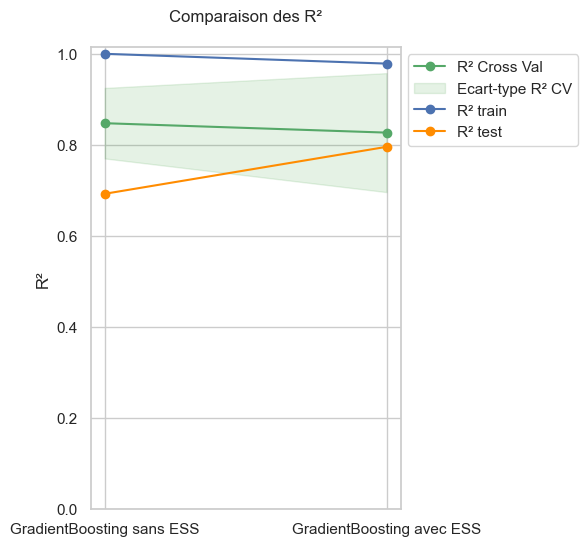

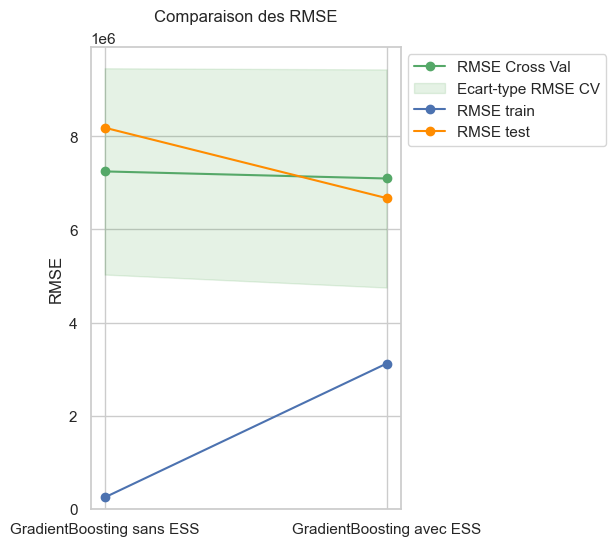

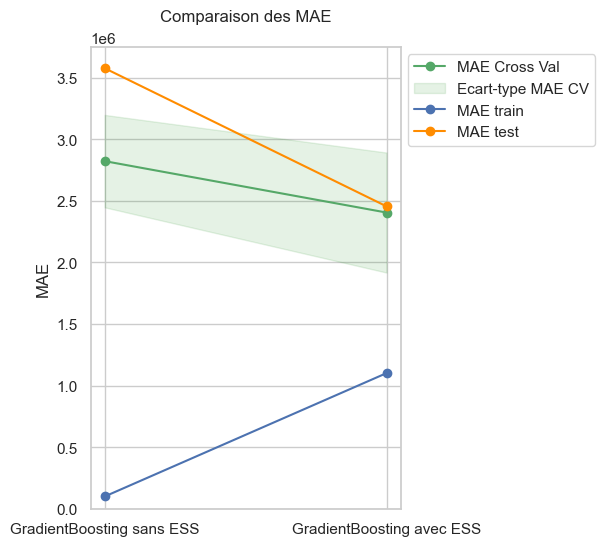

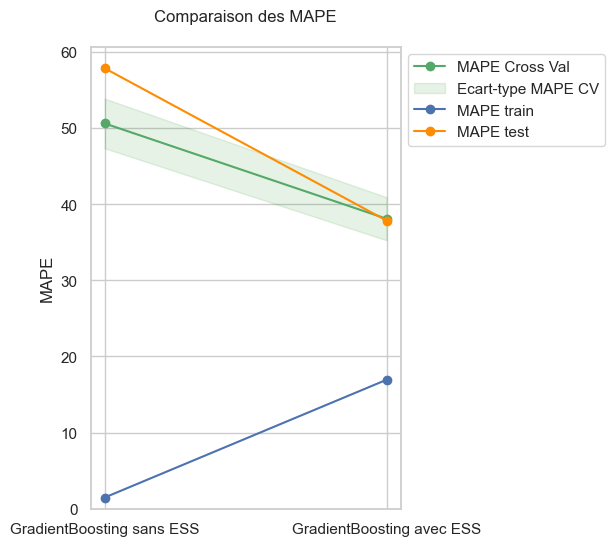

In [109]:
# Comparatif des scores sous forme de plot :
for i in ['R²', 'RMSE', 'MAE', 'MAPE']:
    compare_scores(i)

In [110]:
# Extraction du régresseur du pipeline :
best_regressor = gbr_star_best_model.named_steps['transformedtargetregressor'].regressor
best_regressor.fit(One_Hot_Encoder(Xs_train), np.log(y_train))

GradientBoostingRegressor(learning_rate=0.3, min_samples_leaf=2,
                          min_samples_split=5, random_state=11, subsample=0.75)

In [111]:
# Création de l'explainer SHAP pour GradientBoostingRegressor :
explainer = shap.TreeExplainer(best_regressor)

In [112]:
# Calcul des valeurs SHAP pour toutes les instances de X_test :
shap_values = explainer.shap_values(One_Hot_Encoder(Xs_test))

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


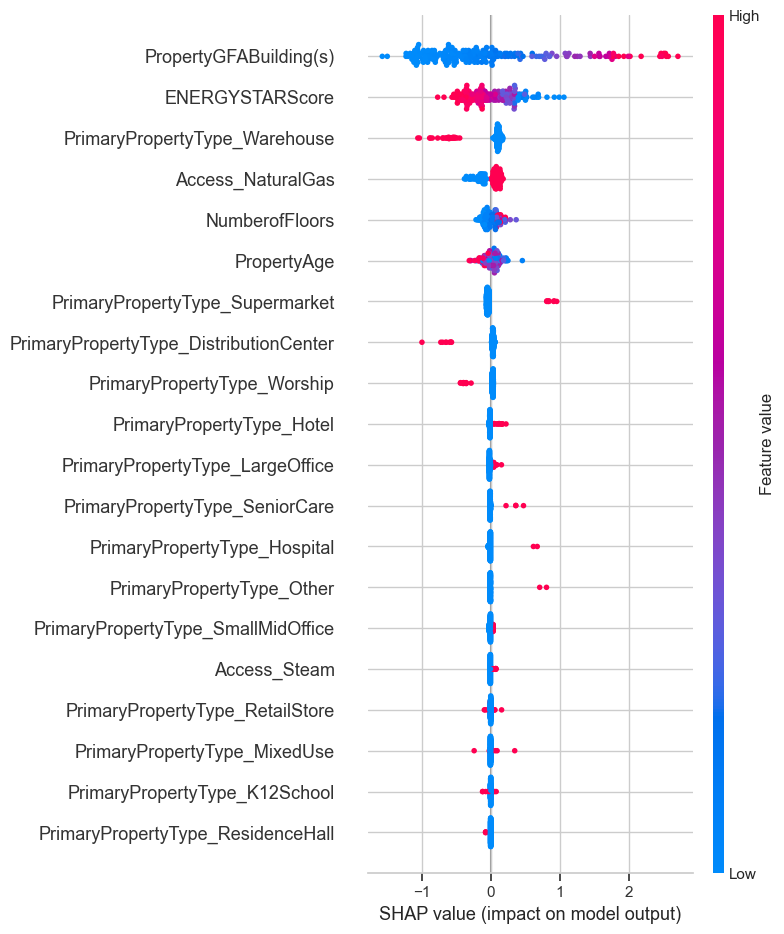

In [113]:
# Affichage de l'interprétabilité globale :
shap.summary_plot(shap_values, One_Hot_Encoder(Xs_test))